In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [69]:
df = pd.read_csv("CC GENERAL.csv")

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [71]:
df = df.drop(columns=['CUST_ID'])


In [72]:
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)


In [73]:
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

In [74]:
X_std = scaler_std.fit_transform(df)
X_mm = scaler_mm.fit_transform(df)


In [75]:

k_values = [2,3,4,5,6]
results = []

for X, scaler_name in [(X_std,"Standard"), (X_mm,"MinMax")]:
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        results.append([scaler_name, "KMeans", k, sil])

results_df = pd.DataFrame(results, columns=["Scaler","Algorithm","k","Silhouette"])
results_df


,Scaler,Algorithm,k,Silhouette
0,Standard,KMeans,2,0.279540
1,Standard,KMeans,3,0.206718
2,Standard,KMeans,4,0.166460
3,Standard,KMeans,5,0.192566
4,Standard,KMeans,6,0.192292
5,MinMax,KMeans,2,0.386742
6,MinMax,KMeans,3,0.372419
7,MinMax,KMeans,4,0.369080
8,MinMax,KMeans,5,0.319508
9,MinMax,KMeans,6,0.322130


In [77]:
for k in [3,4,5]:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_std)
    sil = silhouette_score(X_std, labels)
    results.append(["Standard","Hierarchical", k, sil])


In [79]:
eps_values = [0.5, 1.0, 1.5]
min_samples_values = [5,10]

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_std)

        # ignore noise for silhouette
        mask = labels != -1
        if len(set(labels[mask])) > 1:
            sil = silhouette_score(X_std[mask], labels[mask])
        else:
            sil = None

        results.append(["Standard","DBSCAN", f"eps={eps},ms={ms}", sil])


In [80]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)


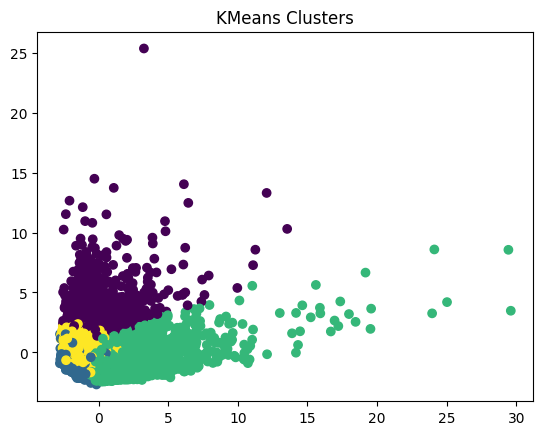

In [81]:
km = KMeans(n_clusters=4, random_state=42)
labels = km.fit_predict(X_std)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("KMeans Clusters")
plt.show()


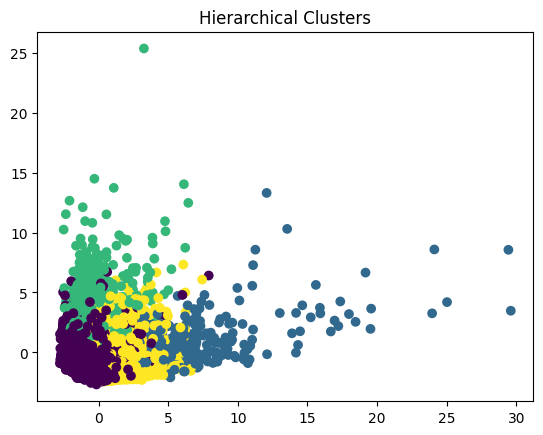

In [82]:
hc = AgglomerativeClustering(n_clusters=4)
labels = hc.fit_predict(X_std)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("Hierarchical Clusters")
plt.show()


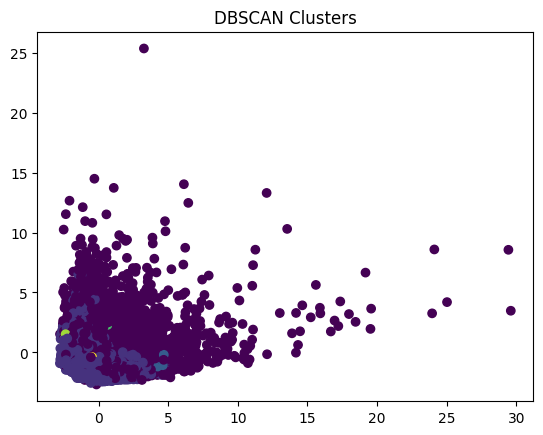

In [84]:
db = DBSCAN(eps=1.2, min_samples=5)
labels = db.fit_predict(X_std)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("DBSCAN Clusters")
plt.show()



In [85]:
results_df = pd.DataFrame(results, columns=["Scaler","Algorithm","k or params","Silhouette"])
results_df


,Scaler,Algorithm,k or params,Silhouette
0,Standard,KMeans,2,0.279540
1,Standard,KMeans,3,0.206718
2,Standard,KMeans,4,0.166460
3,Standard,KMeans,5,0.192566
4,Standard,KMeans,6,0.192292
5,MinMax,KMeans,2,0.386742
6,MinMax,KMeans,3,0.372419
7,MinMax,KMeans,4,0.369080
8,MinMax,KMeans,5,0.319508
9,MinMax,KMeans,6,0.322130
